In [6]:
"""
Ontology Coverage Analysis
==========================
Evaluates how well an OWL ontology (TTL) covers the vocabulary
of a corpus of insurance contracts using KeyBERT keyphrase extraction.
"""

import os
import glob
import re
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from rdflib import Graph, RDFS, OWL, RDF

from sentence_transformers import SentenceTransformer, util
from rapidfuzz import fuzz
from nltk.corpus import wordnet
import nltk

nltk.download("wordnet")


[nltk_data] Downloading package wordnet to /home/mridum/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
CONTRACTS_DIR   = "../dataset/contracts"
EXTRACTED_PHRASES_PATH = "../dataset/extracted_keyphrases.json"
ONTOLOGY_PATH   = "../dataset/ontologies/life_insurance_tbox.ttl"

In [8]:
def load_contracts(directory: str) -> dict[str, str]:
    contracts = {}
    for path in sorted(glob.glob(os.path.join(directory, "*.txt"))):
        name = Path(path).stem
        with open(path, "r", encoding="utf-8") as f:
            contracts[name] = f.read()
    print(f"Loaded {len(contracts)} contracts: {list(contracts.keys())}")
    return contracts



def extract_keyphrases(phrases_path: str) -> list[str]:

    with open(phrases_path, "r", encoding="utf-8") as f:
        terms_by_contract = json.load(f)
    
    keyphrases = []
    seen = set()
    for contract_terms in terms_by_contract.values():
        for term in contract_terms:
            term = term.lower().strip()
            if term not in seen:
                keyphrases.append(term)
                seen.add(term)
    
    print(f" Extracted {len(keyphrases)} unique keyphrases from the contracts")
    return keyphrases



def load_ontology_labels(ttl_path: str) -> set[str]:
    """
    Extract human-readable labels from the ontology.
    Pulls rdfs:label, and also derives labels from class/property local names
    by splitting CamelCase and underscore tokens.
    """
    g = Graph()
    g.parse(ttl_path, format="turtle")

    labels = set()


    def camel_to_words(text: str) -> str:
        s1 = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', text)
        s2 = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s1)
        
        return s2.replace("_", " ").strip().lower()

    for _, _, label in g.triples((None, RDFS.label, None)):
        labels.add(str(label).lower().strip())


    for rdf_type in (OWL.Class, OWL.ObjectProperty, OWL.DatatypeProperty,
                     OWL.NamedIndividual, RDF.Property):
        for subj, _, _ in g.triples((None, RDF.type, rdf_type)):
            local = str(subj).split("#")[-1].split("/")[-1]
            if local:
                labels.add(camel_to_words(local))

    print(f"Loaded {len(labels)} ontology labels/concepts")
    return labels


def normalize(text: str) -> str:
    return re.sub(r"[^a-z0-9 ]", "", text.lower().strip())


def map_keyphrases(keyphrases: list[tuple[str, float]],
                   ontology_labels: set[str],
                   sem_model: SentenceTransformer,
                   ontology_embeddings,
                   ont_labels_list: list[str]) -> pd.DataFrame:
    """
    For each keyphrase, check if it (or any of its sub-tokens) matches
    an ontology label. Partial/substring matching counts as a match,
    reflecting that near-synonyms are an acceptable mapping.
    """
    norm_labels = {normalize(l) for l in ontology_labels}

    rows = []
    for phrase in keyphrases:

        norm_phrase = normalize(phrase)

        match_type = None

        phrase_words = set(norm_phrase.split())

        matched_labels_substring = sorted(
            [
                lbl for lbl in norm_labels
                if all(word in set(lbl.split()) for word in phrase_words)
            ],
            key=lambda x: len(x.split())
        )
        
        matched_labels_fuzzy = [lbl for lbl in norm_labels if fuzz.token_sort_ratio(norm_phrase, lbl) >= 70]
        
        phrase_emb = sem_model.encode(phrase, convert_to_tensor=True)
        sim_scores = util.cos_sim(phrase_emb, ontology_embeddings)[0]

        matched_indices = (sim_scores >= 0.70).nonzero(as_tuple=True)[0]
        matched_labels_semantic = []
        if len(matched_indices) > 0:
            matched_labels_semantic = sorted(
                [(ont_labels_list[i], float(sim_scores[i])) for i in matched_indices],
                key=lambda x: x[1], 
                reverse=True
            )

        is_substring = len(matched_labels_substring) > 0
        is_fuzzy = len(matched_labels_fuzzy) > 0
        is_semantic = len(matched_labels_semantic) > 0

        match_label = None
        if is_substring: match_label = matched_labels_substring[0]
        elif is_fuzzy: match_label = matched_labels_fuzzy[0]
        elif is_semantic: match_label = matched_labels_semantic[0][0]

        rows.append({
            "keyphrase": phrase,
            "is_substring": is_substring,
            "is_fuzzy": is_fuzzy and not is_substring,
            "is_semantic": is_semantic and not (is_substring or is_fuzzy),
            "mapped": is_substring or is_fuzzy or is_semantic,
            "matched_ontology_label": match_label
        })

    df = pd.DataFrame(rows)
    mapped   = df["mapped"].sum()
    total    = len(df)
    coverage = mapped / total * 100
    print(f"Coverage: {mapped}/{total} keyphrases mapped ({coverage:.1f}%)")


    return df

In [9]:
contracts  = load_contracts(CONTRACTS_DIR)

Loaded 10 contracts: ['contract_10_indexed_universal', 'contract_1_term_life', 'contract_2_whole_life', 'contract_3_universal_life', 'contract_4_variable_universal', 'contract_5_final_expense', 'contract_6_group_term', 'contract_7_term_with_riders', 'contract_8_joint_survivorship', 'contract_9_return_of_premium']


In [10]:
keyphrases = extract_keyphrases(EXTRACTED_PHRASES_PATH)
print(keyphrases)


 Extracted 416 unique keyphrases from the contracts
['term life policy', 'level term policy', 'death benefit', 'level death benefit', 'face amount', 'policy term', 'coverage in force', 'policy expiry date', 'policy owner', 'insured', 'primary beneficiary', 'contingent beneficiary', 'beneficiary designation', 'beneficiary change provision', 'beneficiary share percentage', 'premium payment', 'level premium', 'premium payment frequency', 'monthly premium', 'premium due date', 'premium due day of month', 'automatic premium deduction', 'grace period', 'grace period days', 'premium nonpayment grace period', 'coverage continues during grace period', 'policy lapse', 'coverage termination', 'suicide exclusion', 'suicide exclusion period', 'return of premiums paid', 'incontestability provision', 'contestability period', 'misstatement of age provision', 'misstatement of sex provision', 'death benefit adjustment', 'conversion privilege', 'conversion to permanent policy', 'conversion maximum age', 

In [11]:
ontology_labels = load_ontology_labels(ONTOLOGY_PATH)
print(ontology_labels)

Loaded 404 ontology labels/concepts
{'mortality and expense charge', 'has cap rate', 'accumulate at interest dividend option', 'index account (iul)', 'pre-existing condition exclusion', 'insurer name', 'exclusion', 'risk class', 'policy number', 'variable sub-account crediting', 'adb maximum amount', 'policy loan', 'reinstatement interest rate', 'unit value (vul)', 'accumulation units (vul)', 'waiver disability waiting months', 'primary beneficiary', 'has charge', 'non forfeiture option', 'monthly premium amount', 'dividend option', 'policy issuance', 'accidental death benefit rider', 'terminal illness adb', 'beneficiary change provision', 'has primary beneficiary', 'indexed universal life (iul) policy', 'policy anniversary day', 'fixed interest crediting', 'cap rate guaranteed minimum', 'separate account', 'return of premium benefit', 'insurer', 'transaction fee', 'standard', 'reinstatement period years', 'source contract id', 'guaranteed insurability option rider', 'insurer website',

In [12]:
sem_model = SentenceTransformer("all-MiniLM-L6-v2")
ontology_embeddings = sem_model.encode(list(ontology_labels), convert_to_tensor=True)
ont_labels_list = list(ontology_labels)

results_df = map_keyphrases(keyphrases, ontology_labels, sem_model, ontology_embeddings, ont_labels_list)


/home/mridum/miniconda3/envs/ontology/lib/python3.11/site-packages/torch/nn/modules/module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Coverage: 352/416 keyphrases mapped (84.6%)


In [13]:
print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
total    = len(results_df)
mapped   = results_df["mapped"].sum()
coverage = mapped / total * 100
print(f"  Total keyphrases extracted : {total}")
print(f"  Mapped to ontology         : {mapped}")
print(f"  Unmapped (potential gaps)  : {total - mapped}")
print(f"  Coverage score             : {coverage:.1f}%")
print("=" * 60)

print("\n  10 UNMAPPED terms:")
unmapped = results_df[~results_df["mapped"]].head(10)
for _, row in unmapped.iterrows():
    print(f"    - '{row['keyphrase']}'")


  SUMMARY
  Total keyphrases extracted : 416
  Mapped to ontology         : 352
  Unmapped (potential gaps)  : 64
  Coverage score             : 84.6%

  10 UNMAPPED terms:
    - 'automatic premium deduction'
    - 'coverage continues during grace period'
    - 'written notice of assignment'
    - 'lump sum payment'
    - 'proof of death'
    - 'claim payment days'
    - 'tax-deferred accumulation'
    - 'outstanding loan'
    - 'loan interest compounding'
    - 'total indebtedness'


In [14]:
def get_mapping_examples(df: pd.DataFrame) -> dict:
    examples = {}

    def format_tuple(row):
        return f"('{row['keyphrase']}',\n'{row['matched_ontology_label']}')"

    sub = df[df["is_substring"] == True]
    if not sub.empty:
        examples['substring'] = format_tuple(sub.iloc[4])
    
    fuz = df[df["is_fuzzy"] == True]
    if not fuz.empty:
        examples['fuzzy'] = format_tuple(fuz.iloc[24])

    sem = df[df["is_semantic"] == True]
    if not sem.empty:
        examples['semantic'] = format_tuple(sem.iloc[7])

    unm = df[df["mapped"] == False]
    if not unm.empty:
        examples['unmapped'] = f"Unmapped:\n'{unm.iloc[1]['keyphrase']}'"

    return examples

In [15]:
def plot_ontology_coverage(df: pd.DataFrame, examples: dict[str, str]):

    exact_count = df["is_substring"].sum()
    fuzzy_count = df["is_fuzzy"].sum()
    semantic_count = df["is_semantic"].sum()
    total_mapped = df["mapped"].sum()
    unmapped = len(df) - total_mapped
    total_phrases = len(df)
    coverage_pct = (total_mapped / total_phrases) * 100

    categories = ['Exact / \nSubstring', 'Fuzzy \nMatch', 'Semantic \n(cosine≥0.70)', 'Total \nMapped', 'Unmapped']
    counts = [exact_count, fuzzy_count, semantic_count, total_mapped, unmapped]
    colors = ['#64a5f2', '#7db973', '#a452bd', '#3262b9', '#de6255']

    label_examples = [
        (0, f"e.g., {examples['substring']}"),
        (1, f"e.g., {examples['fuzzy']}"),
        (2, f"e.g., {examples['semantic']}"),
        (4, f"e.g., {examples['unmapped']}")
    ]

    plt.figure(figsize=(5, 6)) 
    sns.set_style("ticks")
    
    ax = sns.barplot(x=categories, y=counts, palette=colors, width=0.8)

    for i, v in enumerate(counts):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

    plt.axhline(y=total_phrases, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    plt.text(4.2, total_phrases + 5, f"{total_phrases} total", color='grey', fontsize=10)

    plt.annotate(f'{coverage_pct:.1f}% Coverage', 
                 xy=(3, total_mapped), xytext=(3, total_mapped + 40),
                 bbox=dict(boxstyle='round,pad=0.5', fc='#f0f7ff', ec='#3262b9', lw=1),
                 fontsize=10, color='#3262b9', fontweight='bold', ha='center')

    for idx, text in label_examples:
            val = counts[idx]
            ax.text(idx, val + 25, text, 
                    ha='center', va='bottom',
                    fontsize=10, 
                    fontstyle='italic', 
                    color='#555555',
                    rotation=90)

    plt.xticks(rotation=30)
    plt.ylabel("Number of Keyphrases")
    plt.ylim(0, total_phrases + 10) 
    sns.despine()
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3906043/387830125.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=categories, y=counts, palette=colors, width=0.8)


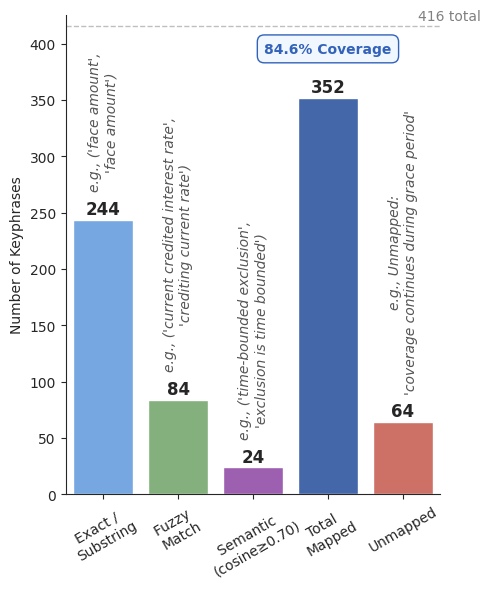

In [16]:
examples = get_mapping_examples(results_df)
plot_ontology_coverage(results_df, examples)